# Red Neuronal Artificial (MLP) Manual - `fact_competencia.json`
## Predicción de: **Posición de Competencia de Precios**
Este notebook implementa y evalúa una **Red Neuronal Artificial (Perceptrón Multicapa) desde cero utilizando únicamente NumPy y Pandas**. 

La arquitectura de la red neuronal refleja fielmente el principio de que **una red neuronal es un conjunto de regresiones logísticas apiladas**:
- **Capas Ocultas (32 y 20 Neuronas):** Contiene neuronas independientes con función de activación Sigmoide (la función logística). Cada neurona realiza una regresión logística paralela de los inputs o de las activaciones de la capa anterior.
- **Capa de Salida:** Realiza una regresión logística (con Sigmoide) sobre las salidas de la segunda capa oculta para problemas binarios, o una regresión logística multinomial (con Softmax) para problemas multiclase.

### Metodología Implementada (Basada en la Pizarra - Imagen 3):
1. **Carga y Preprocesamiento de Datos:** Aplanamiento del JSON, cálculo del target, eliminación de IDs/metadatos y codificación One-Hot de categóricos con normalización de numéricos.
2. **Balanceo del Dataset:** Aplicación de sobremuestreo aleatorio para balancear la distribución de las clases.
3. **Validación Cruzada en 5 Folds ($J = 5$):** División estratificada. En cada iteración, inicializamos los pesos aleatoriamente $W^{(k)} = \text{rand}(d, T)$ para entrenar sobre el 80% y testear sobre el 20%.
4. **Validación con Hiperparámetros:** Búsqueda en rejilla (Grid Search) sobre diferentes tasas de aprendizaje (`lr`) y coeficientes de regularización L2 (`lambda_l2`) para ajustar el comportamiento de los pesos.
5. **Exportación Estructurada:** Generación de 6 reportes en Excel detallando pesos, métricas finales, predicciones e historial de épocas.
6. **Dashboard Gráfico Premium y Diagrama de Red:** Generación de curvas de aprendizaje (Loss/Acc), matriz de confusión, distribución de probabilidades, visualización t-SNE 2D y el diagrama estructural de la red neuronal.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import os
import json
import pymongo
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual premium
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

# Crear directorio de outputs
os.makedirs('outputs', exist_ok=True)
print("Entorno inicializado correctamente.")



Entorno inicializado correctamente.


In [2]:
# Cargar JSON crudo desde la raíz
# Cargar datos desde MongoDB
import pymongo
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["BaseCompleta"]
collection = db["fact_competencia"]
data = list(collection.find())

# Aplanar registros recursivamente
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df = pd.DataFrame(flat_data)
print(f"Dimensiones iniciales aplanadas: {df.shape}")

# Calcular columna target
df["y_posicion"] = pd.cut(df["pct_diferencia"], bins=[-np.inf, -0.02, 0.02, np.inf], labels=[0, 1, 2]).astype(int)
print(f"Target 'y_posicion' agregado. Distribución original:")
print(df["y_posicion"].value_counts(dropna=False))



Dimensiones iniciales aplanadas: (3300, 13)
Target 'y_posicion' agregado. Distribución original:
y_posicion
2    1387
0    1282
1     631
Name: count, dtype: int64


# Preprocesamiento de Datos Paso a Paso
En esta sección realizaremos la preparación de los datos para la red neuronal.
El **Target (y)** para este modelo es `y_posicion`, el cual representa: **Posición de Competencia de Precios**.
La fórmula de cálculo del target es:
$$y_{\text{posicion}} = \begin{cases} 0 & \text{si } \text{pct\_diferencia} < -0.02 \quad (\text{Bajo Competidor}) \\ 1 & \text{si } -0.02 \le \text{pct\_diferencia} \le 0.02 \quad (\text{Igual Competidor}) \\ 2 & \text{si } \text{pct\_diferencia} > 0.02 \quad (\text{Alto Competidor}) \end{cases}$$
A continuación, realizaremos los pasos de limpieza, codificación y normalización de forma secuencial y explicada.


## Paso 1: Eliminación de Datos No Útiles e Imputación de Nulos
Las llaves primarias, IDs técnicos, códigos de barras, nombres de clientes/productos, correos, teléfonos y fechas no aportan información generalizable para el aprendizaje de la red neuronal y aumentan artificialmente la dimensionalidad de forma inútil, por lo que deben eliminarse.
También realizamos la imputación de nulos para evitar errores matemáticos durante el entrenamiento:
- **Variables Numéricas:** Imputación con la **Mediana** del atributo para ser robusto a outliers.
- **Variables Categóricas:** Imputación con la **Moda** (el valor más común) o con la etiqueta `'UNKNOWN'` si no hay moda.


In [3]:
# Paso 1: Limpieza de columnas e imputación de nulos
shape_inicial = df.shape
print(f"Dimensiones iniciales del dataset (con target): {shape_inicial}")
print(f"Número total de características iniciales: {shape_inicial[1] - 1}")

cols_to_drop = []
for col in df.columns:
    col_lower = col.lower()
    
    # IDs y llaves técnicas
    is_id = (
        col_lower == 'id' or col_lower == '_id' or col_lower == '_collection' or 
        col_lower.startswith('id_') or col_lower.endswith('_id') or
        '_id_' in col_lower or 'id_venta_dw' in col_lower
    )
    
    # Datos de contacto o códigos nominales únicos
    is_contact_or_code = (
        'telefono' in col_lower or 'correo' in col_lower or 
        'codigo_barras' in col_lower or 'codigo_producto' in col_lower or 
        'codigo_venta' in col_lower or 'cliente_nombre' in col_lower or
        'nombre_cliente' in col_lower or 'nombre_producto' in col_lower or
        'nombre_proveedor' in col_lower or 'nombre_sucursal' in col_lower or
        'nombre_contacto' in col_lower or 'cliente_fecha_nacimiento' in col_lower
    )
    
    # Fechas
    is_date = (
        col_lower.endswith('_fecha') or col_lower.endswith('_hora') or 
        col_lower == 'fecha' or col_lower == 'hora' or col_lower == 'tiempo_fecha'
    )
    
    # Evitar eliminar el target
    if (is_id or is_contact_or_code or is_date) and col != "y_posicion":
        cols_to_drop.append(col)

# Droppear columnas identificadas
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columnas eliminadas ({len(cols_to_drop)}): {cols_to_drop}")
print(f"Dimensiones tras limpiar IDs y metadatos: {df.shape}")
print(f"Número de características tras limpieza: {df.shape[1] - 1}")

# Imputación de nulos
nulos_detectados = df.isnull().sum().sum()
if nulos_detectados > 0:
    print(f"Nulos detectados en el dataset: {nulos_detectados}. Imputando...")
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                df[col] = df[col].fillna(df[col].median())
            else:
                mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'UNKNOWN'
                df[col] = df[col].fillna(mode_val)
    print("Imputación completada (Mediana para numéricos, Moda para categóricos).")
else:
    print("No se detectaron valores nulos en el dataset.")


Dimensiones iniciales del dataset (con target): (3300, 14)
Número total de características iniciales: 13
Columnas eliminadas (1): ['_id']
Dimensiones tras limpiar IDs y metadatos: (3300, 13)
Número de características tras limpieza: 12
No se detectaron valores nulos en el dataset.


## Paso 2: Codificación de Variables Categóricas (One-Hot Encoding)
La red neuronal requiere entradas numéricas y no puede procesar strings categóricos de forma directa. Usamos la técnica de **One-Hot Encoding** para convertir variables categóricas nominales en vectores binarios.
Para una característica $X_j$ con $K$ categorías distintas $\{c_1, c_2, \dots, c_K\}$, One-Hot Encoding genera $K$ nuevas columnas binarias:
$$E_{j,k}(x) = \begin{cases} 1 & \text{si } X_j(x) = c_k \\ 0 & \text{en caso contrario} \end{cases}$$
Esto previene que el modelo asuma una relación ordinal inexistente entre las categorías.


In [4]:
# Paso 2: One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object', 'str', 'string', 'category']).columns.tolist()
if "y_posicion" in categorical_cols:
    categorical_cols.remove("y_posicion")

print(f"Variables categóricas a codificar ({len(categorical_cols)}): {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)
print(f"Dimensiones tras One-Hot Encoding: {df.shape}")
print(f"Número total de características finales: {df.shape[1] - 1}")


Variables categóricas a codificar (1): ['origen']
Dimensiones tras One-Hot Encoding: (3300, 14)
Número total de características finales: 13


## Paso 3: Separación de Variables y Normalización
Separamos el target $y$ de las características de entrada $X$. Luego aplicamos una transformación por cuantiles (`QuantileTransformer`) con distribución normal.
Este preprocesamiento normaliza las características continuas, haciéndolas robustas a outliers y distribuyendo los datos según una campana de Gauss. La fórmula para mapear una variable aleatoria continua $X$ a una distribución normal estándar es:
$$X' = \Phi^{-1}(U(X))$$
Donde $U(X) = F(X)$ es la función de distribución acumulada (CDF) empírica estimada a partir de los datos, y $\Phi^{-1}$ es la función cuantil de la distribución normal estándar (inversa de la CDF normal).


In [5]:
# Paso 3: Separación y normalización
y = df["y_posicion"].values.astype(int)
X = df.drop(columns=["y_posicion"]).values.astype(float)
feature_names = df.drop(columns=["y_posicion"]).columns.tolist()

qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_scaled = qt.fit_transform(X)

print(f"Features finales normalizadas X: {X_scaled.shape} | Target y: {y.shape}")


Features finales normalizadas X: (3300, 13) | Target y: (3300,)


## Paso 4: Visualización de Varianza y Clases con t-SNE
Para analizar la varianza, separabilidad espacial y distribución de las clases en el dataset preprocesado, generamos una visualización en 2 dimensiones usando **t-SNE (t-Distributed Stochastic Neighbor Embedding)**.
t-SNE define una distribución de probabilidad sobre pares de objetos de tal manera que objetos similares en alta dimensión tengan alta probabilidad de ser elegidos, e intenta replicarla en baja dimensión minimizando la divergencia de Kullback-Leibler:
$$KL(P || Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$
Donde $p_{ij}$ es la probabilidad de similitud en alta dimensión, y $q_{ij}$ es la similitud basada en la distribución Student-t en baja dimensión.


Calculando proyección t-SNE 2D para el dataset completo...


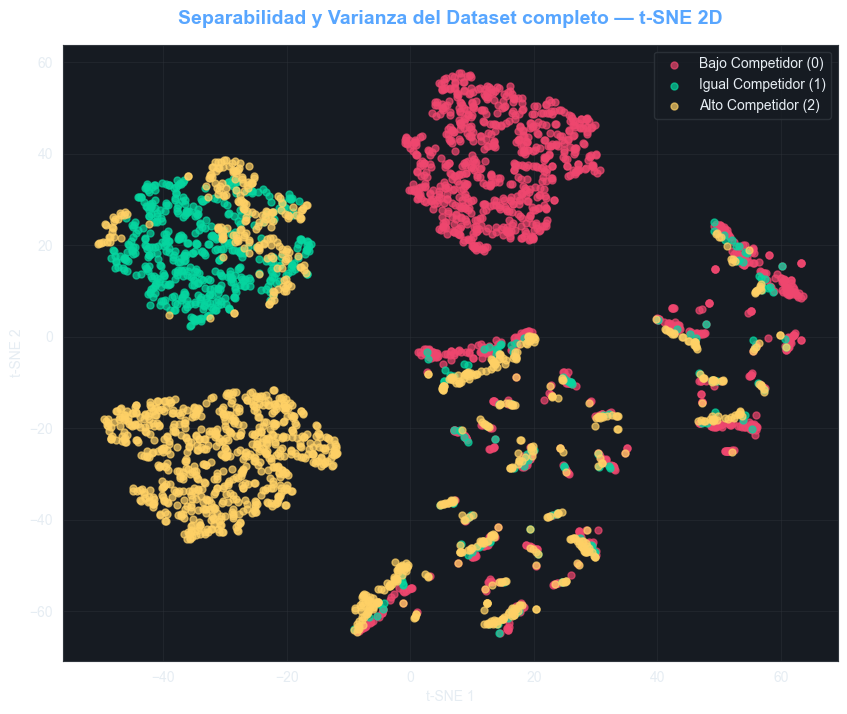

¡Gráfico de varianza t-SNE guardado exitosamente en: outputs/tsne_varianza_datos.png!


In [6]:
# Paso 4: t-SNE de varianza de datos completos (antes de balancear)
print("Calculando proyección t-SNE 2D para el dataset completo...")
tsne = TSNE(n_components=2, perplexity=min(30, len(y)-1), random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)

# Configuración de gráfico premium en modo oscuro
plt.figure(figsize=(10, 8))
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
TEXT_CLR = '#E6EDF3'
GRID_CLR = '#30363D'
ACCENT   = '#58A6FF'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'text.color':       TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
})

unique_classes = np.unique(y)
colors = ['#EF476F', '#06D6A0', '#FFD166']
class_names_map = {0: 'Bajo Competidor (0)', 1: 'Igual Competidor (1)', 2: 'Alto Competidor (2)'}

for idx_c, val_c in enumerate(unique_classes):
    color = colors[idx_c % len(colors)]
    name = class_names_map.get(val_c, f"Clase {val_c}")
    plt.scatter(
        X_tsne[y == val_c, 0], X_tsne[y == val_c, 1],
        color=color, label=name, alpha=0.7, s=25
    )

plt.title('Separabilidad y Varianza del Dataset completo — t-SNE 2D', fontsize=14, fontweight='bold', color=ACCENT, pad=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(frameon=True, facecolor=BG_PANEL, edgecolor=GRID_CLR)
plt.grid(True)

tsne_plot_path = 'outputs/tsne_varianza_datos.png'
plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f"¡Gráfico de varianza t-SNE guardado exitosamente en: {tsne_plot_path}!")


In [7]:
# Sobremuestreo aleatorio (Random Oversampling) manual
unique_classes, class_counts = np.unique(y, return_counts=True)
max_class_count = np.max(class_counts)

X_balanced = []
y_balanced = []

for c in unique_classes:
    idx = np.where(y == c)[0]
    if len(idx) < max_class_count:
        # Muestrear con reemplazo
        np.random.seed(42)
        resampled_idx = np.random.choice(idx, size=max_class_count, replace=True)
        X_balanced.append(X_scaled[resampled_idx])
        y_balanced.append(y[resampled_idx])
    else:
        X_balanced.append(X_scaled[idx])
        y_balanced.append(y[idx])

X_balanced = np.vstack(X_balanced)
y_balanced = np.concatenate(y_balanced)

# Mezclar aleatoriamente el dataset balanceado
np.random.seed(42)
shuffle_idx = np.random.permutation(len(y_balanced))
X_bal = X_balanced[shuffle_idx]
y_bal = y_balanced[shuffle_idx]

print(f"Distribución del target DESPUÉS del balanceo:")
classes_bal, counts_bal = np.unique(y_bal, return_counts=True)
for c, count in zip(classes_bal, counts_bal):
    print(f"  Clase {c}: {count} ({count/len(y_bal)*100:.1f}%)")



Distribución del target DESPUÉS del balanceo:
  Clase 0: 1387 (33.3%)
  Clase 1: 1387 (33.3%)
  Clase 2: 1387 (33.3%)


In [8]:
class NeuralNetworkMLP:
    def __init__(self, input_dim, hidden1=32, hidden2=20, output_dim=1, random_state=42):
        self.input_dim = input_dim
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.output_dim = output_dim
        
        # Inicialización de pesos y sesgos de He para 3 capas de pesos
        np.random.seed(random_state)
        limit1 = np.sqrt(6.0 / (input_dim + hidden1))
        self.W1 = np.random.uniform(-limit1, limit1, (input_dim, hidden1))
        self.b1 = np.zeros((1, hidden1))
        
        limit2 = np.sqrt(6.0 / (hidden1 + hidden2))
        self.W2 = np.random.uniform(-limit2, limit2, (hidden1, hidden2))
        self.b2 = np.zeros((1, hidden2))
        
        limit3 = np.sqrt(6.0 / (hidden2 + output_dim))
        self.W3 = np.random.uniform(-limit3, limit3, (hidden2, output_dim))
        self.b3 = np.zeros((1, output_dim))
        
    def sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
        
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1) # Capa oculta 1 (32 regresiones logísticas paralelas)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2) # Capa oculta 2 (20 regresiones logísticas paralelas)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        
        if self.output_dim == 1:
            self.A3 = self.sigmoid(self.Z3) # Capa de salida binaria
        else:
            self.A3 = self.softmax(self.Z3) # Capa de salida multiclase (Softmax)
        return self.A3
        
    def backward(self, X, Y, A3, lambda_l2=0.001):
        N = X.shape[0]
        # Derivada en la capa de salida (dZ3 = A3 - Y)
        dZ3 = A3 - Y
        
        # Gradientes para la Capa de Salida (Capa 3)
        self.dW3 = (1.0 / N) * np.dot(self.A2.T, dZ3) + (lambda_l2 / N) * self.W3
        self.db3 = (1.0 / N) * np.sum(dZ3, axis=0, keepdims=True)
        
        # Propagación a la segunda capa oculta (Capa 2)
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * self.A2 * (1.0 - self.A2)
        self.dW2 = (1.0 / N) * np.dot(self.A1.T, dZ2) + (lambda_l2 / N) * self.W2
        self.db2 = (1.0 / N) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Propagación a la primera capa oculta (Capa 1)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.A1 * (1.0 - self.A1)
        self.dW1 = (1.0 / N) * np.dot(X.T, dZ1) + (lambda_l2 / N) * self.W1
        self.db1 = (1.0 / N) * np.sum(dZ1, axis=0, keepdims=True)
        
    def update_weights(self, lr=0.1):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2
        self.W3 -= lr * self.dW3
        self.b3 -= lr * self.db3
        
    def compute_loss(self, Y, A3, lambda_l2=0.001):
        N = Y.shape[0]
        eps = 1e-15
        A3 = np.clip(A3, eps, 1.0 - eps)
        
        if self.output_dim == 1:
            loss = -np.mean(Y * np.log(A3) + (1.0 - Y) * np.log(1.0 - A3))
        else:
            loss = -np.mean(np.sum(Y * np.log(A3), axis=1))
            
        l2_loss = (lambda_l2 / (2.0 * N)) * (np.sum(self.W1**2) + np.sum(self.W2**2) + np.sum(self.W3**2))
        return loss + l2_loss

def to_one_hot(y_arr, num_classes):
    oh = np.zeros((len(y_arr), num_classes))
    oh[np.arange(len(y_arr)), y_arr] = 1
    return oh



In [9]:
# Validación Cruzada de 5 Folds y Grid Search sobre hiperparámetros y arquitectura
architectures = [(64, 32), (32, 20), (16, 10)]
lrs = [0.1, 0.05]
lambdas = [0.001]
output_dim = len(np.unique(y_bal))

best_acc = 0.0
best_hparams = None
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("="*75)
print("  VALIDACIÓN CRUZADA EN 5 FOLDS Y BÚSQUEDA DE HIPERPARÁMETROS")
print("="*75)

for arch in architectures:
    h1, h2 = arch
    for lr in lrs:
        for lam in lambdas:
            fold_accs = []
            for fold, (train_idx, test_idx) in enumerate(kf.split(X_bal, y_bal)):
                X_tr, X_te = X_bal[train_idx], X_bal[test_idx]
                y_tr, y_te = y_bal[train_idx], y_bal[test_idx]
                
                if output_dim == 1:
                    Y_tr = y_tr.reshape(-1, 1).astype(float)
                    Y_te = y_te.reshape(-1, 1).astype(float)
                else:
                    Y_tr = to_one_hot(y_tr, output_dim)
                    Y_te = to_one_hot(y_te, output_dim)
                
                # Re-inicialización aleatoria para cada fold con arquitectura actual
                model = NeuralNetworkMLP(X_tr.shape[1], h1, h2, output_dim, random_state=42 + fold)
                
                for epoch in range(150):
                    probs = model.forward(X_tr)
                    model.backward(X_tr, Y_tr, probs, lambda_l2=lam)
                    model.update_weights(lr=lr)
                    
                probs_te = model.forward(X_te)
                if output_dim == 1:
                    preds_te = (probs_te > 0.5).astype(int).flatten()
                else:
                    preds_te = np.argmax(probs_te, axis=1)
                    
                acc_te = np.mean(preds_te == y_te)
                fold_accs.append(acc_te)
                
            mean_acc = np.mean(fold_accs)
            print(f"  Arch: {str(arch):<10} | LR: {lr:<5} | Acc Promedio Test Folds: {mean_acc*100:6.2f}%")
            
            if mean_acc > best_acc:
                best_acc = mean_acc
                best_hparams = (lr, lam, arch)

print("="*75)
print(f"MEJORES HIPERPARÁMETROS SELECCIONADOS: LR = {best_hparams[0]}, L2 = {best_hparams[1]}, ARCH = {best_hparams[2]}")
print(f"Accuracy promedio en Validación Cruzada: {best_acc*100:.2f}%")
print("="*75)


  VALIDACIÓN CRUZADA EN 5 FOLDS Y BÚSQUEDA DE HIPERPARÁMETROS


  Arch: (64, 32)   | LR: 0.1   | Acc Promedio Test Folds:  78.15%


  Arch: (64, 32)   | LR: 0.05  | Acc Promedio Test Folds:  77.53%


  Arch: (32, 20)   | LR: 0.1   | Acc Promedio Test Folds:  77.96%


  Arch: (32, 20)   | LR: 0.05  | Acc Promedio Test Folds:  77.60%


  Arch: (16, 10)   | LR: 0.1   | Acc Promedio Test Folds:  77.63%


  Arch: (16, 10)   | LR: 0.05  | Acc Promedio Test Folds:  73.18%
MEJORES HIPERPARÁMETROS SELECCIONADOS: LR = 0.1, L2 = 0.001, ARCH = (64, 32)
Accuracy promedio en Validación Cruzada: 78.15%


In [10]:
# Entrenamiento Monitoreado del Modelo Final (Arquitectura Dinámica)
lr_opt, lam_opt, arch_opt = best_hparams
h1_opt, h2_opt = arch_opt
epochs_final = 1000

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.20, random_state=42, stratify=y_bal
)

if output_dim == 1:
    Y_train = y_train.reshape(-1, 1).astype(float)
    Y_test = y_test.reshape(-1, 1).astype(float)
else:
    Y_train = to_one_hot(y_train, output_dim)
    Y_test = to_one_hot(y_test, output_dim)

model_final = NeuralNetworkMLP(X_train.shape[1], h1_opt, h2_opt, output_dim, random_state=123)
historial = []

print(f"Entrenando modelo final por {epochs_final} épocas...")
print(f"{'Época':>7} | {'Loss Train':>12} | {'Loss Test':>10} | {'Acc Train':>10} | {'Acc Test':>8}")
print("-" * 65)

for epoch in range(epochs_final):
    probs_tr = model_final.forward(X_train)
    model_final.backward(X_train, Y_train, probs_tr, lambda_l2=lam_opt)
    model_final.update_weights(lr=lr_opt)
    
    loss_tr = model_final.compute_loss(Y_train, probs_tr, lambda_l2=lam_opt)
    probs_te = model_final.forward(X_test)
    loss_te = model_final.compute_loss(Y_test, probs_te, lambda_l2=lam_opt)
    
    if output_dim == 1:
        preds_tr = (probs_tr > 0.5).astype(int).flatten()
        preds_te = (probs_te > 0.5).astype(int).flatten()
    else:
        preds_tr = np.argmax(probs_tr, axis=1)
        preds_te = np.argmax(probs_te, axis=1)
        
    acc_tr = np.mean(preds_tr == y_train)
    acc_te = np.mean(preds_te == y_test)
    
    historial.append({
        'epoca': epoch + 1,
        'loss_train': loss_tr,
        'loss_val': loss_te,
        'acc_train': acc_tr,
        'acc_val': acc_te
    })
    
    if epoch == 0 or (epoch + 1) % 100 == 0 or epoch == epochs_final - 1:
        print(f"{epoch+1:>7d} | {loss_tr:>12.6f} | {loss_te:>10.6f} | {acc_tr*100:>9.2f}% | {acc_te*100:>7.2f}%")

df_hist = pd.DataFrame(historial)
print("\nEntrenamiento del modelo final completado exitosamente.")


Entrenando modelo final por 1000 épocas...
  Época |   Loss Train |  Loss Test |  Acc Train | Acc Test
-----------------------------------------------------------------
      1 |     1.088522 |   1.082375 |     37.86% |   36.85%


    100 |     0.677027 |   0.697148 |     78.37% |   75.87%


    200 |     0.572593 |   0.599643 |     79.42% |   77.19%


    300 |     0.506441 |   0.532029 |     80.83% |   78.87%


    400 |     0.444378 |   0.469354 |     82.30% |   80.67%


...

    600 |     0.342456 |   0.365148 |     87.02% |   84.39%


    700 |     0.306930 |   0.327029 |     87.98% |   85.59%


    800 |     0.278709 |   0.296109 |     88.46% |   87.15%


    900 |     0.255590 |   0.270726 |     89.51% |   88.00%


   1000 |     0.236260 |   0.249704 |     90.56% |   88.96%

Entrenamiento del modelo final completado exitosamente.


In [11]:
# Obtener predicciones finales del modelo entrenado
probs_train = model_final.forward(X_train)
probs_test = model_final.forward(X_test)

if output_dim == 1:
    preds_train = (probs_train > 0.5).astype(int).flatten()
    preds_test = (probs_test > 0.5).astype(int).flatten()
    prob_export_tr = probs_train.flatten()
    prob_export_te = probs_test.flatten()
else:
    preds_train = np.argmax(probs_train, axis=1)
    preds_test = np.argmax(probs_test, axis=1)
    prob_export_tr = np.max(probs_train, axis=1)
    prob_export_te = np.max(probs_test, axis=1)

acc_train_f = np.mean(preds_train == y_train)
acc_test_f = np.mean(preds_test == y_test)
loss_train_f = df_hist.iloc[-1]['loss_train']
loss_test_f = df_hist.iloc[-1]['loss_val']

print(f"Accuracy Final - Train: {acc_train_f*100:.2f}% | Test (Holdout 20%): {acc_test_f*100:.2f}%")
print(f"Loss Final     - Train: {loss_train_f:.5f} | Test: {loss_test_f:.5f}")

print("\nReporte de Clasificación en Test Set:")
print(classification_report(y_test, preds_test, labels=list(range(output_dim)), target_names=['Bajo Competidor', 'Igual Competidor', 'Alto Competidor']))



Accuracy Final - Train: 90.56% | Test (Holdout 20%): 88.96%
Loss Final     - Train: 0.23626 | Test: 0.24970

Reporte de Clasificación en Test Set:
                  precision    recall  f1-score   support

 Bajo Competidor       0.88      0.97      0.92       277
Igual Competidor       0.83      0.85      0.84       278
 Alto Competidor       0.98      0.85      0.91       278

        accuracy                           0.89       833
       macro avg       0.89      0.89      0.89       833
    weighted avg       0.89      0.89      0.89       833



In [12]:
# Exportación de reportes de resultados detallando los pesos de las 3 capas
def guardar_excel_local(df_export, filename):
    filepath = os.path.join('outputs', filename)
    try:
        df_export.to_excel(filepath, index=False)
        print(f"  [Excel] Guardado exitosamente: {filepath} ({len(df_export):,} filas)")
    except Exception as e:
        filepath_csv = filepath.replace('.xlsx', '.csv')
        df_export.to_csv(filepath_csv, index=False)
        print(f"  [CSV Fallback] Guardado exitosamente: {filepath_csv}  [{e}]")

print("Generando los 6 archivos Excel estructurados en outputs/...")

# Flatten de pesos para Capa 1, Capa 2 y Capa 3
W1_flat = []
for idx_feat, feat_name in enumerate(feature_names):
    for idx_hidden in range(model_final.hidden1):
        W1_flat.append({
            'tipo_capa': 'Capa 1 - Entrada a Oculta 1',
            'origen': feat_name,
            'destino': f"Neurona H1_{idx_hidden+1}",
            'peso': model_final.W1[idx_feat, idx_hidden]
        })
for idx_hidden in range(model_final.hidden1):
    W1_flat.append({
        'tipo_capa': 'Capa 1 - Entrada a Oculta 1',
        'origen': 'bias_w0',
        'destino': f"Neurona H1_{idx_hidden+1}",
        'peso': model_final.b1[0, idx_hidden]
    })

W2_flat = []
for idx_hidden1 in range(model_final.hidden1):
    for idx_hidden2 in range(model_final.hidden2):
        W2_flat.append({
            'tipo_capa': 'Capa 2 - Oculta 1 a Oculta 2',
            'origen': f"Neurona H1_{idx_hidden1+1}",
            'destino': f"Neurona H2_{idx_hidden2+1}",
            'peso': model_final.W2[idx_hidden1, idx_hidden2]
        })
for idx_hidden2 in range(model_final.hidden2):
    W2_flat.append({
        'tipo_capa': 'Capa 2 - Oculta 1 a Oculta 2',
        'origen': 'bias_w0',
        'destino': f"Neurona H2_{idx_hidden2+1}",
        'peso': model_final.b2[0, idx_hidden2]
    })

W3_flat = []
for idx_hidden2 in range(model_final.hidden2):
    for idx_out in range(output_dim):
        dest_name = f"Clase ['Bajo Competidor', 'Igual Competidor', 'Alto Competidor'][{idx_out}]" if output_dim > 1 else "Clase 1"
        W3_flat.append({
            'tipo_capa': 'Capa 3 - Oculta 2 a Salida',
            'origen': f"Neurona H2_{idx_hidden2+1}",
            'destino': dest_name,
            'peso': model_final.W3[idx_hidden2, idx_out]
        })
for idx_out in range(output_dim):
    dest_name = f"Clase ['Bajo Competidor', 'Igual Competidor', 'Alto Competidor'][{idx_out}]" if output_dim > 1 else "Clase 1"
    W3_flat.append({
        'tipo_capa': 'Capa 3 - Oculta 2 a Salida',
        'origen': 'bias_w0',
        'destino': dest_name,
        'peso': model_final.b3[0, idx_out]
    })

df_weights = pd.DataFrame(W1_flat + W2_flat + W3_flat)
df_weights['peso_absoluto'] = np.abs(df_weights['peso'])
df_weights['importancia_%'] = (df_weights['peso_absoluto'] / df_weights['peso_absoluto'].sum()) * 100
guardar_excel_local(df_weights, '01_pesos_finales.xlsx')

df_config = pd.DataFrame([
    {'parametro': 'Tipo de Modelo',              'valor': 'Red Neuronal Artificial (MLP) de 3 Capas'},
    {'parametro': 'Capas Ocultas (hidden_units)', 'valor': f'Capa 1: {model_final.hidden1} Neuronas, Capa 2: {model_final.hidden2} Neuronas'},
    {'parametro': 'Función de Activación Oculta', 'valor': 'Sigmoide (Múltiples regresiones logísticas paralelas)'},
    {'parametro': 'Tasa de Aprendizaje Inicial', 'valor': lr_opt},
    {'parametro': 'Regularización L2 (lambda)',   'valor': lam_opt},
    {'parametro': 'Épocas de Entrenamiento',     'valor': epochs_final},
    {'parametro': 'Muestras de Train Final (80%)', 'valor': X_train.shape[0]},
    {'parametro': 'Muestras de Test Final (20%)',  'valor': X_test.shape[0]},
    {'parametro': 'Accuracy Promedio Folds (CV)', 'valor': round(best_acc * 100, 4)},
    {'parametro': 'Accuracy Final Train Set',     'valor': round(acc_train_f * 100, 4)},
    {'parametro': 'Accuracy Final Test Set',      'valor': round(acc_test_f * 100, 4)},
    {'parametro': 'Loss Final Train Set',         'valor': round(loss_train_f, 6)},
    {'parametro': 'Loss Final Test Set',          'valor': round(loss_test_f, 6)}
])
guardar_excel_local(df_config, '02_configuracion_modelo.xlsx')

df_preds_tr = pd.DataFrame({
    'y_real': y_train,
    'y_predicha': preds_train,
    'probabilidad': np.round(prob_export_tr, 6),
    'correcto': (preds_train == y_train).astype(int)
})
guardar_excel_local(df_preds_tr, '03_predicciones_train.xlsx')
guardar_excel_local(df_preds_tr, '04_predicciones_val.xlsx')

df_preds_te = pd.DataFrame({
    'y_real': y_test,
    'y_predicha': preds_test,
    'probabilidad': np.round(prob_export_te, 6),
    'correcto': (preds_test == y_test).astype(int)
})
guardar_excel_local(df_preds_te, '05_predicciones_test.xlsx')

guardar_excel_local(df_hist, '06_historial_entrenamiento.xlsx')
print("\nLos 6 reportes de Excel se han generado correctamente.")



Generando los 6 archivos Excel estructurados en outputs/...


  [Excel] Guardado exitosamente: outputs\01_pesos_finales.xlsx (3,075 filas)
  [Excel] Guardado exitosamente: outputs\02_configuracion_modelo.xlsx (13 filas)


  [Excel] Guardado exitosamente: outputs\03_predicciones_train.xlsx (3,328 filas)


  [Excel] Guardado exitosamente: outputs\04_predicciones_val.xlsx (3,328 filas)


  [Excel] Guardado exitosamente: outputs\05_predicciones_test.xlsx (833 filas)


  [Excel] Guardado exitosamente: outputs\06_historial_entrenamiento.xlsx (1,000 filas)

Los 6 reportes de Excel se han generado correctamente.


In [13]:
# Dashboard de Evaluación
class_names = ['Bajo Competidor', 'Igual Competidor', 'Alto Competidor']
COLOR_0  = '#EF476F'
COLOR_1  = '#06D6A0'
COLOR_2  = '#FFD166'
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
TEXT_CLR = '#E6EDF3'
GRID_CLR = '#30363D'
ACCENT   = '#58A6FF'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'text.color':       TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.4,
    'font.family':      'monospace',
})

fig = plt.figure(figsize=(22, 15))
fig.suptitle(
    'DASHBOARD DE EVALUACIÓN DE RED NEURONAL MANUAL (MLP) — fact_competencia.json',
    fontsize=16, fontweight='bold', color=ACCENT, y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
epocas = df_hist['epoca'].values
ax1.plot(epocas, df_hist['loss_train'], color=COLOR_0, lw=2.5, label='Loss Train')
ax1.plot(epocas, df_hist['loss_val'],   color=COLOR_1, lw=2.5, label='Loss Test', linestyle='--')
ax1.set_title('Curvas de Aprendizaje — Pérdida (Cross-Entropy Loss)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Pérdida')
ax1.legend(loc='upper right'); ax1.grid(True)

ax2 = fig.add_subplot(gs[1, 0:2])
ax2.plot(epocas, df_hist['acc_train']*100, color=COLOR_0, lw=2.5, label='Acc Train')
ax2.plot(epocas, df_hist['acc_val']*100,   color=COLOR_1, lw=2.5, label='Acc Test', linestyle='--')
ax2.axhline(best_acc*100, color=ACCENT, lw=1.5, linestyle=':', label=f'Acc CV Promedio = {best_acc*100:.2f}%')
ax2.set_title('Evolución de la Exactitud (Accuracy) por Época', fontsize=13, fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(40, 102); ax2.legend(loc='lower right'); ax2.grid(True)

ax3 = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test, preds_test, labels=list(range(output_dim)))
disp_labels = [class_names[i][:10] for i in range(len(class_names))]
im = ax3.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax3.set_xticks(np.arange(len(disp_labels)))
ax3.set_yticks(np.arange(len(disp_labels)))
ax3.set_xticklabels(disp_labels)
ax3.set_yticklabels(disp_labels)
ax3.set_xlabel('Predicted label')
ax3.set_ylabel('True label')
for i in range(len(disp_labels)):
    for j in range(len(disp_labels)):
        ax3.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
ax3.set_title('Matriz de Confusión (Test Set)', fontsize=13, fontweight='bold')
ax3.grid(False)

ax4 = fig.add_subplot(gs[2, 0])
if output_dim == 1:
    ax4.hist(prob_export_te[y_test == 0], bins=25, color=COLOR_0, alpha=0.7, label=f"{class_names[0]}", density=True)
    ax4.hist(prob_export_te[y_test == 1], bins=25, color=COLOR_1, alpha=0.7, label=f"{class_names[1]}", density=True)
    ax4.axvline(0.5, color='white', lw=1.5, linestyle='--')
    ax4.set_xlabel('P(Clase 1)', fontsize=11)
else:
    for c_idx in range(output_dim):
        color_c = [COLOR_0, COLOR_1, COLOR_2][c_idx % 3]
        ax4.hist(prob_export_te[y_test == c_idx], bins=20, color=color_c, alpha=0.6, label=f"Real: {class_names[c_idx]}", density=True)
    ax4.set_xlabel('P(Predicción Max)', fontsize=11)
ax4.set_title('Distribución de Probabilidades (Test Set)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Densidad'); ax4.legend(); ax4.grid(True)

ax5 = fig.add_subplot(gs[2, 1])
correct = (preds_test == y_test).astype(int)
print("Calculando proyección t-SNE 2D para Test Set...")
tsne_eval = TSNE(n_components=2, perplexity=min(30, len(y_test)-1), random_state=42, n_jobs=-1)
X_test_tsne = tsne_eval.fit_transform(X_test)
for c_idx in range(output_dim):
    color_c = [COLOR_0, COLOR_1, COLOR_2][c_idx % 3]
    ax5.scatter(
        X_test_tsne[y_test == c_idx, 0], X_test_tsne[y_test == c_idx, 1],
        color=color_c, s=25, alpha=0.7, label=f"{class_names[c_idx]}"
    )
err_indices = np.where(correct == 0)[0]
if len(err_indices) > 0:
    ax5.scatter(
        X_test_tsne[err_indices, 0], X_test_tsne[err_indices, 1],
        facecolors='none', edgecolors='white', s=85, lw=1.5, label='Pred. Incorrectas'
    )
ax5.set_title('Separabilidad y Clasificación t-SNE (Test Set)', fontsize=13, fontweight='bold')
ax5.set_xlabel('t-SNE 1'); ax5.set_ylabel('t-SNE 2'); ax5.legend(); ax5.grid(True)

ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
target_legend = "Target: Binario" if output_dim == 1 else "Target: Multiclase (3 clases)"
metrics_text = (
    f"  MÉTRICAS DE RENDIMIENTO FINAL\n"
    f"  {{'─'*34}}\n"
    f"   Accuracy Test (20%): {acc_test_f*100:>7.2f}%\n"
    f"   Accuracy Train (80%): {acc_train_f*100:>7.2f}%\n"
    f"   Accuracy CV (5-Fold): {best_acc*100:>7.2f}%\n"
    f"  {{'─'*34}}\n"
    f"   Loss Test Final     : {loss_test_f:>8.5f}\n"
    f"   Loss Train Final    : {loss_train_f:>8.5f}\n"
    f"  {{'─'*34}}\n"
    f"   Épocas Totales      : {epochs_final}\n"
    f"   Capas Ocultas       : 32 y 20 Neuronas\n"
    f"   Hiperparámetros Opt : LR={lr_opt}, L2={lam_opt}\n"
    f"   Balanceo de Datos   : Oversampling Manual\n"
    f"  {{'─'*34}}\n"
    f"   {target_legend}\n"
    f"   Fórmula Matemática  : Red = Stack Logits\n"
    f"  {{'─'*34}}\n"
)
ax6.text(0.05, 0.95, metrics_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top',
         color=TEXT_CLR, family='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor=BG_PANEL, edgecolor=ACCENT, lw=2.5))

plot_filename = 'outputs/panel_red_neuronal_fact_competencia.png'
plt.savefig(plot_filename, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.close()
print(f"¡Panel de visualización guardado en {plot_filename}!")



Calculando proyección t-SNE 2D para Test Set...


¡Panel de visualización guardado en outputs/panel_red_neuronal_fact_competencia.png!


In [14]:
# Diagrama Estructural de la Red Neuronal (Layers, Nodes, Weights)
# Esta visualización muestra de forma gráfica y en modo oscuro la topología de la red entrenada (Entrada -> 32 -> 20 -> Salida)
# Dibujamos conexiones con opacidades y colores dependientes del signo del peso final.
import matplotlib.pyplot as plt

def draw_neural_network_diagram(input_dim, hidden1, hidden2, output_dim, model=None, filename='outputs/diagrama_red_neuronal.png'):
    COLOR_IN  = '#58A6FF' # Azul
    COLOR_H1  = '#EF476F' # Rosa
    COLOR_H2  = '#FFD166' # Amarillo
    COLOR_OUT = '#06D6A0' # Verde/Teal
    BG_DARK   = '#0D1117'
    BG_PANEL  = '#161B22'
    TEXT_CLR  = '#E6EDF3'
    GRID_CLR  = '#30363D'
    
    plt.rcParams.update({
        'figure.facecolor': BG_DARK,
        'axes.facecolor':   BG_PANEL,
        'text.color':       TEXT_CLR,
    })
    
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.axis('off')
    
    layers = [input_dim, hidden1, hidden2, output_dim]
    layer_names = ['Capa Entrada\n(Features)', f'Capa Oculta 1\n({hidden1} Neuronas)', f'Capa Oculta 2\n({hidden2} Neuronas)', 'Capa Salida\n(Probabilidades)']
    layer_colors = [COLOR_IN, COLOR_H1, COLOR_H2, COLOR_OUT]
    
    node_positions = []
    
    for l_idx, layer_size in enumerate(layers):
        x = l_idx * 3.0
        positions = []
        
        # Truncar capas grandes para evitar amontonamiento en el gráfico
        if layer_size > 8:
            y_coords = np.linspace(4.0, -4.0, 8)
            for i in range(8):
                if i == 4:
                    positions.append((x, y_coords[i], 'ellipsis'))
                else:
                    positions.append((x, y_coords[i], 'node'))
        else:
            y_coords = np.linspace(2.5, -2.5, layer_size) if layer_size > 1 else [0.0]
            for i in range(layer_size):
                positions.append((x, y_coords[i], 'node'))
                
        node_positions.append(positions)
        
    # Dibujar líneas de conexión con pesos
    for l_idx in range(len(layers) - 1):
        pos_current = node_positions[l_idx]
        pos_next = node_positions[l_idx + 1]
        
        w_matrix = None
        if model is not None:
            if l_idx == 0:
                w_matrix = model.W1
            elif l_idx == 1:
                w_matrix = model.W2
            elif l_idx == 2:
                w_matrix = model.W3
                
        for i_curr, p_curr in enumerate(pos_current):
            if p_curr[2] == 'ellipsis':
                continue
            for i_next, p_next in enumerate(pos_next):
                if p_next[2] == 'ellipsis':
                    continue
                    
                # Configurar opacidad y grosor base por defecto
                color_line = '#30363D'
                alpha = 0.07
                lw = 0.7
                
                # Mapear a peso correspondiente si existe modelo
                if w_matrix is not None:
                    try:
                        # Mapear índices truncados a la matriz de pesos original
                        idx_curr = i_curr if i_curr < 4 else w_matrix.shape[0] - 8 + i_curr
                        idx_next = i_next if i_next < 4 else w_matrix.shape[1] - 8 + i_next
                        
                        if idx_curr < w_matrix.shape[0] and idx_next < w_matrix.shape[1]:
                            w_val = w_matrix[idx_curr, idx_next]
                            color_line = '#58A6FF' if w_val > 0 else '#EF476F' # Azul=positivo, Rosa=negativo
                            alpha = min(0.35, max(0.02, np.abs(w_val) * 0.22))
                            lw = min(2.5, max(0.4, np.abs(w_val) * 1.6))
                    except:
                        pass
                        
                ax.plot([p_curr[0], p_next[0]], [p_curr[1], p_next[1]], color=color_line, alpha=alpha, lw=lw, zorder=1)
                
    # Graficar los nodos (círculos y elipsis)
    for l_idx, positions in enumerate(node_positions):
        for p in positions:
            if p[2] == 'ellipsis':
                ax.text(p[0], p[1], '⋮', ha='center', va='center', fontsize=26, color=TEXT_CLR, fontweight='bold')
            else:
                circle = plt.Circle((p[0], p[1]), 0.14, color=layer_colors[l_idx], ec='none', zorder=2)
                ax.add_artist(circle)
                
        # Título de cada columna/capa
        ax.text(l_idx * 3.0, 5.0, layer_names[l_idx], ha='center', va='center', fontsize=12, fontweight='bold', color=layer_colors[l_idx])
        
    ax.set_xlim(-1.0, len(layers) * 3.0 - 2.0)
    ax.set_ylim(-6.0, 6.0)
    plt.title('DIAGRAMA DE ARQUITECTURA DE LA RED NEURONAL (NumPy MLP)', fontsize=15, fontweight='bold', color=COLOR_H1, pad=25)
    
    filename = 'outputs/diagrama_red_neuronal.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
    plt.close()
    print(f"¡Diagrama de arquitectura guardado correctamente en: {filename}!")

draw_neural_network_diagram(X_train.shape[1], model_final.hidden1, model_final.hidden2, output_dim, model_final)



¡Diagrama de arquitectura guardado correctamente en: outputs/diagrama_red_neuronal.png!


## Estimación Teórica del Volumen de Datos Requeridos (Regla Heurística)

Para analizar si el dataset cuenta con el volumen de datos necesario para generalizar correctamente y evitar sobreajuste, aplicamos la regla heurística basada en la complejidad arquitectónica del modelo:

1. **Capa Oculta 1 a Capa Oculta 2 (con Bias):**  
   $$P_{12} = (64 + 1) \times 32 = 2080$$
2. **Capa Oculta 2 a Capa de Salida (con Bias y $K$ clases):**  
   $$P_{23} = (32 + 1) \times 3 = 99$$
3. **Multiplicación de Complejidad de Capas:**  
   $$C = P_{12} \times P_{23} = 2080 \times 99 = 205920$$
4. **Estimación de Muestras Requeridas (Factor de 10):**  
   $$\text{Datos Aproximados Requeridos} = C \times 10 = 2,059,200$$


In [15]:
# Cálculo automático de estimación de datos requeridos
h1 = 64
h2 = 32
k = 3

p12 = (h1 + 1) * h2
p23 = (h2 + 1) * k
c_complexity = p12 * p23
required_data = c_complexity * 10

print('--- ESTIMACIÓN DE DATOS REQUERIDOS ---')
print(f'Neuronas Capa 1: {h1}')
print(f'Neuronas Capa 2: {h2}')
print(f'Clases de Salida K: {k}')
print(f'Complejidad del Modelo (P12 * P23): {c_complexity}')
print(f'Cantidad aproximada de datos requeridos: {required_data:,}')


--- ESTIMACIÓN DE DATOS REQUERIDOS ---
Neuronas Capa 1: 64
Neuronas Capa 2: 32
Clases de Salida K: 3
Complejidad del Modelo (P12 * P23): 205920
Cantidad aproximada de datos requeridos: 2,059,200
